## Static interrupt

In [31]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

In [32]:
llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [33]:
# Create Tools
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [45]:
# Create LLM that can call tools 
tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

In [46]:
sys_msg = SystemMessage(content="Do the required arithmetic using tools or use your own knowledge to answer the query")

def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


In [47]:
# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)


memory = InMemorySaver()
react_graph = builder.compile(interrupt_before=["tools"], checkpointer= memory)


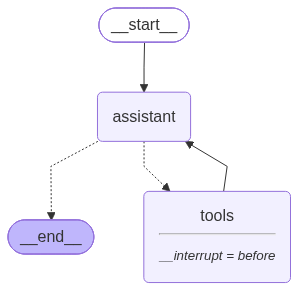

In [37]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

### Example with Tool call and interruption

In [48]:
# Thread
config = {"configurable": {"thread_id": "1"}}

In [ ]:
messages = [HumanMessage(content="Add 3 and 4")]

In [49]:
messages = [HumanMessage(content="what is the capital of Germany")]

In [50]:
response = react_graph.invoke({"messages": messages}, config)

In [51]:
state = react_graph.get_state(config)
print(state)
print(state.next)

StateSnapshot(values={'messages': [HumanMessage(content='what is the capital of Germany', additional_kwargs={}, response_metadata={}, id='e586e613-81ae-4038-9344-8e749a7d0816'), AIMessage(content=[{'type': 'text', 'text': 'The capital of Germany is Berlin.', 'extras': {'signature': 'Cu4BARFNMg8Ep2+loboXdZaSalu6r5lONHRsjGxre9ZMihHHQD5N0DvBgErMd/HyfV7qvE37YCTk5YFm5OgqMrRQmvuhVmzS7MWSUdzMkdRrUkJNOaRjitd6mHVyYLBKd8qYYtlD74s6hGKKBANJWBCLahExX9NfavynlaRVs5Bcewi1ZOMFGxSTVuvp4MuM40Pcfamigx6ENUYLdNb3/wDAirP5NCAeVp2BI48UwFSqj0iBXiQ1vOyeQjZupjxkyzK0D1qro2N0+2uR11dfsqsPjIntTfkSj1p6k72tHi5+dU0utN0nRjiwI7EtE3x1/Q=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fcad0-0003-7913-b81f-12b14fa18f95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 166, 'output_tokens': 44, 'total_tokens': 210, 'input_token_details': {'cache_read': 0}, 'output_token_det

In [53]:
if len(state.next) > 0 and state.next[0] == "tools":  # graph is interruped as next node is tools 
    # Get user feedback
    user_approval = input("Do you want to call the tool? (yes/no): ")

    # Check approval
    if user_approval.lower() == "yes":
        # If approved, resume the graph execution
        response = react_graph.invoke(None, config)
    else:
        print("Sorry!! Operation cancelled by user.")

In [54]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is the capital of Germany
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The capital of Germany is Berlin.', 'extras': {'signature': 'Cu4BARFNMg8Ep2+loboXdZaSalu6r5lONHRsjGxre9ZMihHHQD5N0DvBgErMd/HyfV7qvE37YCTk5YFm5OgqMrRQmvuhVmzS7MWSUdzMkdRrUkJNOaRjitd6mHVyYLBKd8qYYtlD74s6hGKKBANJWBCLahExX9NfavynlaRVs5Bcewi1ZOMFGxSTVuvp4MuM40Pcfamigx6ENUYLdNb3/wDAirP5NCAeVp2BI48UwFSqj0iBXiQ1vOyeQjZupjxkyzK0D1qro2N0+2uR11dfsqsPjIntTfkSj1p6k72tHi5+dU0utN0nRjiwI7EtE3x1/Q=='}}]
